## Baseline vs NESTED (Using Synthetic Dataset)

#### Coverage

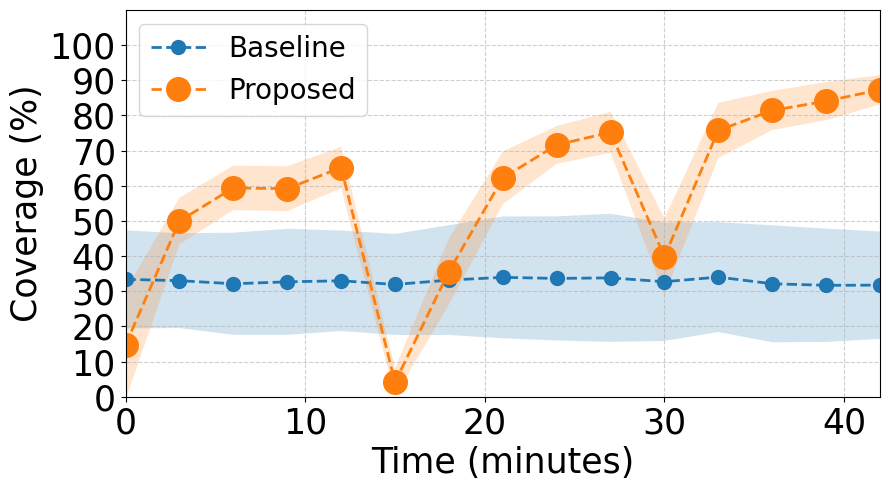

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Load CSV files
baseline_df = pd.read_csv("BASLINE_SYNTHETIC.csv")
proposed_df = pd.read_csv("45_minutes_data.csv")


baseline_df["Iteration No"] = baseline_df["Iteration No"] - 1

baseline_df = baseline_df[baseline_df["Simulation time"] <= 44]
proposed_df = proposed_df[proposed_df["timestamp"] <= 44]


baseline_stats = baseline_df.groupby("Simulation time")["Coverage"].agg(
    mean="mean",
    std="std"
).reset_index()

proposed_stats = proposed_df.groupby("timestamp")["Coverage"].agg(
    mean="mean",
    std="std"
).reset_index()

# Take data after 3 minutes interval
baseline_stats = baseline_stats[
    baseline_stats["Simulation time"] % 3 == 0
]

proposed_stats = proposed_stats[
    proposed_stats["timestamp"] % 3 == 0
]
plt.figure(figsize=(9,5))

plt.plot(
    baseline_stats["Simulation time"],
    baseline_stats["mean"],
    linestyle="--",
    marker="o",
    linewidth=2,
    markersize=10,
    label="Baseline"
)
plt.fill_between(
    baseline_stats["Simulation time"],
    baseline_stats["mean"] - baseline_stats["std"],
    baseline_stats["mean"] + baseline_stats["std"],
    alpha=0.2
)
plt.plot(
    proposed_stats["timestamp"],
    proposed_stats["mean"],
    linestyle="--",
    marker="o",
    linewidth=2,
    markersize=17,
    label="Proposed"
)
plt.fill_between(
    proposed_stats["timestamp"],
    proposed_stats["mean"] - proposed_stats["std"],
    proposed_stats["mean"] + proposed_stats["std"],
    alpha=0.2
)
plt.xlabel("Time (minutes)", fontsize=25)
plt.ylabel("Coverage (%)", fontsize=25)

max_time = max(
    baseline_stats["Simulation time"].max(),
    proposed_stats["timestamp"].max()
)

plt.xlim(0, max_time)
plt.ylim(0, 110)
plt.xticks(np.arange(0, max_time + 1, 10))
plt.yticks(np.arange(0, 110, 10))
ax = plt.gca()
ax.tick_params(axis='both', labelsize=25)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


###### Finding insight

In [4]:
import pandas as pd

baseline_df = pd.read_csv("BASLINE_SYNTHETIC.csv")
proposed_df = pd.read_csv("45_minutes_data.csv")

baseline_df["Iteration No"] -= 1

baseline_df = baseline_df[baseline_df["Simulation time"] <= 75]
proposed_df = proposed_df[proposed_df["timestamp"] <= 75]

baseline_mean = baseline_df.groupby("Simulation time")["Coverage"].mean().reset_index()
proposed_mean = proposed_df.groupby("timestamp")["Coverage"].mean().reset_index()

merged = pd.merge(
    baseline_mean,
    proposed_mean,
    left_on="Simulation time",
    right_on="timestamp",
    suffixes=("_baseline", "_proposed")
)
avg_gain_pp = (
    merged["Coverage_proposed"] - merged["Coverage_baseline"]
).mean()

print(f"Average coverage improvement: {avg_gain_pp:.2f} percentage points")


Average coverage improvement: 29.48 percentage points


## Network Efficiency

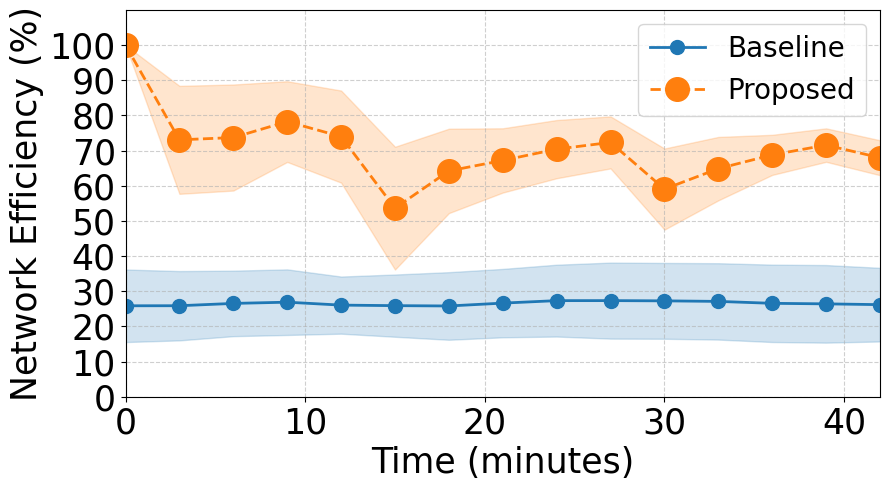

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Load CSV files
baseline_df = pd.read_csv("BASLINE_SYNTHETIC.csv")
proposed_df = pd.read_csv("45_minutes_data.csv")

baseline_df["Iteration No"] = baseline_df["Iteration No"] - 1
baseline_df = baseline_df[baseline_df["Simulation time"] <= 44]
proposed_df = proposed_df[proposed_df["timestamp"] <= 44]

baseline_stats = (
    baseline_df
    .groupby("Simulation time")["Network efficiency"]
    .agg(mean="mean", std="std")
    .reset_index()
)
proposed_stats = (
    proposed_df
    .groupby("timestamp")["network_efficiency"]
    .agg(mean="mean", std="std")
    .reset_index()
)
baseline_stats = baseline_stats[
    baseline_stats["Simulation time"] % 3 == 0
]
proposed_stats = proposed_stats[
    proposed_stats["timestamp"] % 3 == 0
]
baseline_stats[["mean", "std"]] *= 100
proposed_stats[["mean", "std"]] *= 100

max_time = max(
    baseline_stats["Simulation time"].max(),
    proposed_stats["timestamp"].max()
)

plt.figure(figsize=(9, 5))
plt.plot(
    baseline_stats["Simulation time"],
    baseline_stats["mean"],
    linestyle="-",
    marker="o",
    linewidth=2,
    markersize=10,
    color="#1f77b4",
    label="Baseline"
)
plt.fill_between(
    baseline_stats["Simulation time"],
    baseline_stats["mean"] - baseline_stats["std"],
    baseline_stats["mean"] + baseline_stats["std"],
    alpha=0.2,
    color="#1f77b4"
)
plt.plot(
    proposed_stats["timestamp"],
    proposed_stats["mean"],
    linestyle="--",
    marker="o",
    linewidth=2,
    markersize=17,
    color="#ff7f0e",
    label="Proposed"
)
plt.fill_between(
    proposed_stats["timestamp"],
    proposed_stats["mean"] - proposed_stats["std"],
    proposed_stats["mean"] + proposed_stats["std"],
    alpha=0.2,
    color="#ff7f0e"
)
plt.xlabel("Time (minutes)", fontsize=25)
plt.ylabel("Network Efficiency (%)", fontsize=25)
plt.xlim(0, max_time)
plt.ylim(0, 110)
plt.xticks(np.arange(0, max_time + 1, 10))
plt.yticks(np.arange(0, 110, 10))
ax = plt.gca()
ax.tick_params(axis="both", labelsize=25)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


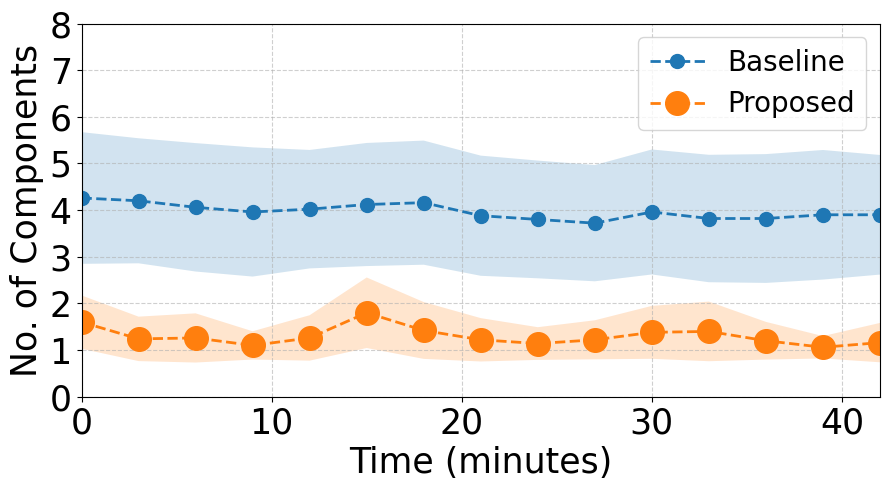

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Load CSV files

baseline_df = pd.read_csv("BASLINE_SYNTHETIC.csv")
proposed_df = pd.read_csv("45_minutes_data.csv")

baseline_df["Iteration No"] = baseline_df["Iteration No"] - 1
baseline_df = baseline_df[baseline_df["Simulation time"] <= 44]
proposed_df = proposed_df[proposed_df["timestamp"] <= 44]

baseline_stats = baseline_df.groupby("Simulation time")["No of connected components"].agg(
    mean="mean",
    std="std"
).reset_index()

proposed_stats = proposed_df.groupby("timestamp")["num_components"].agg(
    mean="mean",
    std="std"
).reset_index()
baseline_stats = baseline_stats[
    baseline_stats["Simulation time"] % 3 == 0
]
max_time=42
proposed_stats = proposed_stats[
    proposed_stats["timestamp"] % 3 == 0
]
plt.figure(figsize=(9,5))
plt.plot(
    baseline_stats["Simulation time"],
    baseline_stats["mean"],
    linestyle="--",
    marker="o",
    linewidth=2,
    markersize=10,
    label="Baseline"
)
plt.fill_between(
    baseline_stats["Simulation time"],
    baseline_stats["mean"] - baseline_stats["std"],
    baseline_stats["mean"] + baseline_stats["std"],
    alpha=0.2
)
plt.plot(
    proposed_stats["timestamp"],
    proposed_stats["mean"],
    linestyle="--",
    marker="o",
    markersize=17,
    linewidth=2,
    label="Proposed"
)
plt.fill_between(
    proposed_stats["timestamp"],
    proposed_stats["mean"] - proposed_stats["std"],
    proposed_stats["mean"] + proposed_stats["std"],
    alpha=0.2
)
plt.xlabel("Time (minutes)", fontsize=25)
plt.ylabel("No. of Components", fontsize=25)
plt.xlim(0, max_time)
plt.ylim(0, 8)
plt.xticks(np.arange(0, max_time + 1, 10))
plt.yticks(np.arange(0, 9, 1))
ax = plt.gca()
ax.tick_params(axis='both', labelsize=25)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=20)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Load CSV files
baseline_df = pd.read_csv("BASLINE_SYNTHETIC.csv")
proposed_df = pd.read_csv("45_minutes_data.csv")

baseline_df["Iteration No"] -= 1
baseline_df = baseline_df[baseline_df["Simulation time"] <= 75]
proposed_df = proposed_df[proposed_df["timestamp"] <= 75]
baseline_mean = (
    baseline_df
    .groupby("Simulation time")["No of connected components"]
    .mean()
    .reset_index(name="baseline_mean")
)

proposed_mean = (
    proposed_df
    .groupby("timestamp")["num_components"]
    .mean()
    .reset_index(name="proposed_mean")
)

merged = pd.merge(
    baseline_mean,
    proposed_mean,
    left_on="Simulation time",
    right_on="timestamp"
)
avg_reduction = (
    merged["baseline_mean"] - merged["proposed_mean"]
).mean()

print(f"Average reduction in connected components: {avg_reduction:.2f}")


Average reduction in connected components: 2.71


In [6]:
import pandas as pd


# Load CSV files
baseline_df = pd.read_csv("BASLINE_SYNTHETIC.csv")
proposed_df = pd.read_csv("45_minutes_data.csv")

baseline_df["Iteration No"] -= 1
baseline_df = baseline_df[baseline_df["Simulation time"] <= 75]
proposed_df = proposed_df[proposed_df["timestamp"] <= 75]
baseline_mean = (
    baseline_df
    .groupby("Simulation time")["Network efficiency"]
    .mean()
    .reset_index(name="NE_baseline")
)
proposed_mean = (
    proposed_df
    .groupby("timestamp")["network_efficiency"]
    .mean()
    .reset_index(name="NE_proposed")
)
merged = pd.merge(
    baseline_mean,
    proposed_mean,
    left_on="Simulation time",
    right_on="timestamp"
)
avg_gain_pp = (
    merged["NE_proposed"] - merged["NE_baseline"]
).mean() * 100   # multiply by 100 to convert to percentage
print(
    f"Average network efficiency improvement: "
    f"{avg_gain_pp:.2f} percentage points"
)


Average network efficiency improvement: 42.63 percentage points
